In [5]:
from HP import _HP, get_script_arguments

In [8]:
import yaml

# Charger le fichier YAML
with open(
    "/Users/jandretti/Documents/PhD/NSA_CVRP_PPO/wandb/Neural_Simulated_Annealing/models/20250131_102349_f054w3c1/HP.yaml",
    "r",
) as file:
    data = yaml.unsafe_load(file)
data.update(get_script_arguments(data.keys()))
data["ALPHA"]   

0.7943282347242815

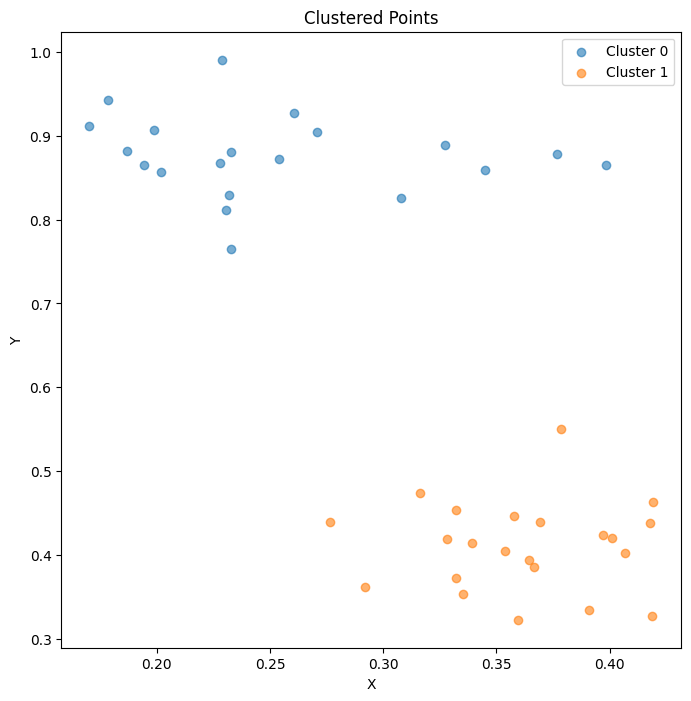

In [8]:
import torch
import matplotlib.pyplot as plt
from typing import Dict


class ProblemGenerator:
    def __init__(self, n_problems: int, dim: int, device: str, num_clusters: int):
        self.n_problems = n_problems
        self.dim = dim
        self.device = device
        self.num_clusters = num_clusters
        self.generator = torch.Generator(device=device)

    def manual_seed(self, seed: int):
        self.generator.manual_seed(seed)

    def generate_params(self, mode: str = "train") -> Dict[str, torch.Tensor]:
        """Generate random coordinates around clusters in the unit square.

        Returns:
            coords [batch size, num problems, 2]
        """
        if mode == "test":
            self.manual_seed(0)

        # Génération des centres de clusters
        cluster_centers = torch.rand(
            self.num_clusters, 2, device=self.device, generator=self.generator
        )

        # Attribution des clusters aux points
        cluster_assignments = torch.randint(
            0,
            self.num_clusters,
            (self.n_problems, self.dim + 1),
            device=self.device,
            generator=self.generator,
        )

        # Génération des coordonnées autour des centres de clusters
        coords = cluster_centers[cluster_assignments] + 0.05 * torch.randn(
            self.n_problems,
            self.dim + 1,
            2,
            device=self.device,
            generator=self.generator,
        )
        coords = torch.clamp(
            coords, 0, 1
        )  # Assurer que les coordonnées restent dans l'unité

        # Génération des demandes
        demands = torch.randint(
            1,
            10,
            (self.n_problems, self.dim + 1),
            device=self.device,
            generator=self.generator,
        )
        demands[:, 0] = 0  # Dépôt sans demande

        return {
            "coords": coords,
            "demands": demands,
            "cluster_assignments": cluster_assignments,
        }

    def plot_clusters(self, params: Dict[str, torch.Tensor]):
        """Plot the generated points with colors corresponding to their cluster assignment."""
        coords = params["coords"].cpu().numpy()
        cluster_assignments = params["cluster_assignments"].cpu().numpy()

        plt.figure(figsize=(8, 8))
        for i in range(self.num_clusters):
            cluster_points = coords[cluster_assignments == i]
            plt.scatter(
                cluster_points[:, 0],
                cluster_points[:, 1],
                label=f"Cluster {i}",
                alpha=0.6,
            )

        plt.xlabel("X")
        plt.ylabel("Y")
        plt.title("Clustered Points")
        plt.legend()
        plt.show()
        
test = ProblemGenerator(2, 20, "cpu", 2)
dict_params = test.generate_params()
test.plot_clusters(dict_params)

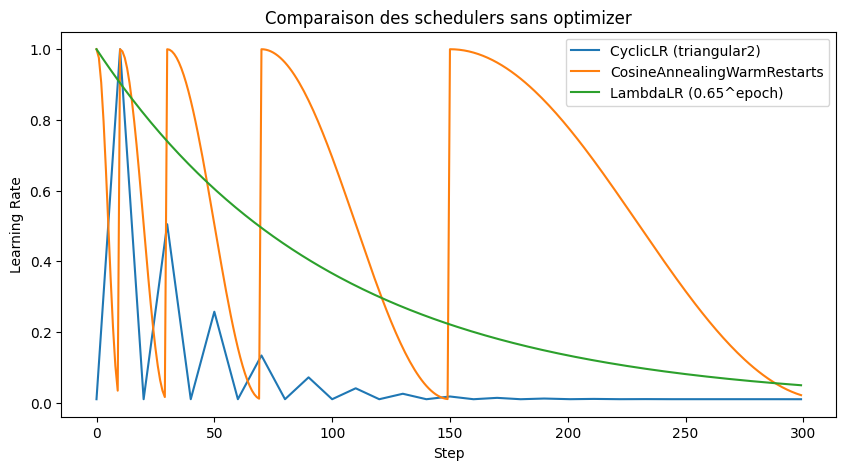

In [19]:
import numpy as np
import matplotlib.pyplot as plt


def cyclic_lr(step, base_lr, max_lr, step_size_up, mode="triangular2"):
    cycle = np.floor(1 + step / (2 * step_size_up))
    x = np.abs(step / step_size_up - 2 * cycle + 1)

    if mode == "triangular":
        return base_lr + (max_lr - base_lr) * np.maximum(0, 1 - x)
    elif mode == "triangular2":
        return base_lr + (max_lr - base_lr) * np.maximum(0, 1 - x) / (2 ** (cycle - 1))
    else:
        raise ValueError("Mode non supporté")


def cosine_annealing_warm_restarts(step, T_0, T_mult, eta_min, eta_max):
    T_cur = step
    T_i = T_0
    while T_cur >= T_i:
        T_cur -= T_i
        T_i *= T_mult
    return eta_min + (eta_max - eta_min) * (1 + np.cos(np.pi * T_cur / T_i)) / 2


def lambda_lr(epoch, initial_lr, factor):
    return initial_lr * (factor**epoch)


# Paramètres
base_lr = 0.01
max_lr = 1
step_size_up = 10
T_0 = 10
T_mult = 2
eta_min = 0.01
eta_max = 1
initial_lr_lambda = 1
lambda_factor = 0.99

# Génération des LR
steps = 300
lrs_cyclic = [
    cyclic_lr(i, base_lr, max_lr, step_size_up, mode="triangular2")
    for i in range(steps)
]
lrs_cosine = [
    cosine_annealing_warm_restarts(i, T_0, T_mult, eta_min, eta_max)
    for i in range(steps)
]
lrs_lambda = [lambda_lr(i, initial_lr_lambda, lambda_factor) for i in range(steps)]

# Affichage
plt.figure(figsize=(10, 5))
plt.plot(lrs_cyclic, label="CyclicLR (triangular2)")
plt.plot(lrs_cosine, label="CosineAnnealingWarmRestarts")
plt.plot(range(300), lrs_lambda, label="LambdaLR (0.65^epoch)")
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.title("Comparaison des schedulers sans optimizer")
plt.legend()
plt.show()

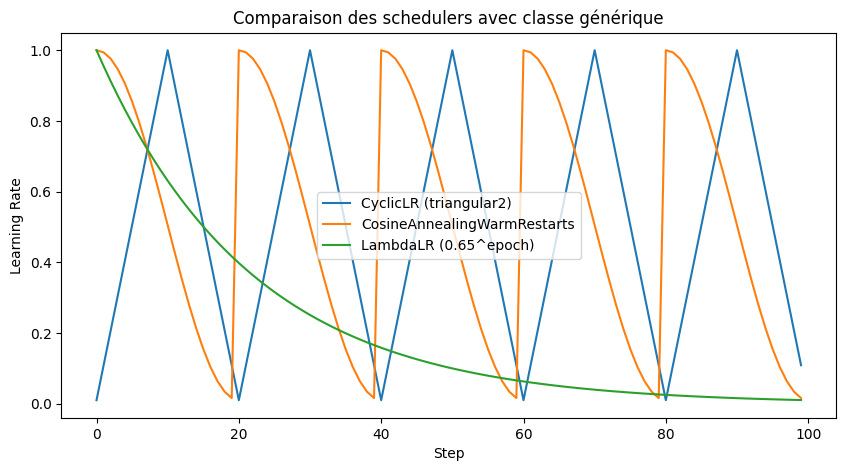

In [38]:
import numpy as np
import matplotlib.pyplot as plt


# Classe Générique pour le scheduler
class LR_Scheduler:
    def __init__(self, scheduler_type, **kwargs):
        self.scheduler_type = scheduler_type
        self.scheduler = None
        if scheduler_type == "cyclic":
            self.scheduler = CyclicLR(**kwargs)
        elif scheduler_type == "cosine":
            self.scheduler = CosineAnnealingWarmRestarts(**kwargs)
        elif scheduler_type == "lambda":
            self.scheduler = LambdaLR(**kwargs)
        else:
            raise ValueError(f"Scheduler de type {scheduler_type} non supporté.")

    def step(self, step):
        return self.scheduler.step(step)


# Classe pour CyclicLR
class CyclicLR:
    def __init__(self, base_lr, max_lr, step_size_up, mode="triangular2"):
        self.base_lr = base_lr
        self.max_lr = max_lr
        self.step_size_up = step_size_up
        self.mode = mode

    def step(self, step):
        cycle = np.floor(1 + step / (2 * self.step_size_up))
        x = np.abs(step / self.step_size_up - 2 * cycle + 1)

        if self.mode == "triangular":
            return self.base_lr + (self.max_lr - self.base_lr) * np.maximum(0, 1 - x)
        elif self.mode == "triangular2":
            return self.base_lr + (self.max_lr - self.base_lr) * np.maximum(
                0, 1 - x
            ) / (2 ** (cycle - 1))
        else:
            raise ValueError("Mode non supporté")


# Classe pour CosineAnnealingWarmRestarts
class CosineAnnealingWarmRestarts:
    def __init__(self, T_0, T_mult, eta_min, eta_max):
        self.T_0 = T_0
        self.T_mult = T_mult
        self.eta_min = eta_min
        self.eta_max = eta_max

    def step(self, step):
        T_cur = step
        T_i = self.T_0
        while T_cur >= T_i:
            T_cur -= T_i
            T_i *= self.T_mult
        return (
            self.eta_min
            + (self.eta_max - self.eta_min) * (1 + np.cos(np.pi * T_cur / T_i)) / 2
        )


# Classe pour LambdaLR
class LambdaLR:
    # def __init__(self, initial_lr, T_max, T_min, step_max):
    #     self.initial_lr = initial_lr
    #     self.T_max = T_max
    #     self.T_min = T_min
    #     self.step_max = step_max
    #     self.lambda_factor = (T_min / T_max) ** (1 / step_max)

    # def step(self, epoch):
    #     return self.initial_lr * (self.lambda_factor**epoch)
    def __init__(self, T_max, T_min, step_max):
        self.T_max = T_max
        self.T_min = T_min
        self.step_max = step_max
        alpha = np.log(T_min) - np.log(T_max)
        self.lambda_factor = np.exp(alpha / step_max)

    def step(self, epoch):
        return self.T_max * (self.lambda_factor**epoch)


# Paramètres de chaque scheduler
steps = 100
base_lr = 0.01
max_lr = 1
step_size_up = 10
T_0 = 20
T_mult = 1
eta_min = 0.01
eta_max = 1
initial_lr_lambda = 1
lambda_factor = 0.99

# Création des instances de chaque scheduler
cyclic_scheduler = LR_Scheduler(
    "cyclic",
    base_lr=base_lr,
    max_lr=max_lr,
    step_size_up=step_size_up,
    mode="triangular",
)
cosine_scheduler = LR_Scheduler(
    "cosine", T_0=T_0, T_mult=T_mult, eta_min=eta_min, eta_max=eta_max
)
lambda_scheduler = LR_Scheduler(
    "lambda", T_max=1, T_min=0.01, step_max=100
)

# Collecte des valeurs de learning rate pour chaque scheduler
lrs_cyclic = [cyclic_scheduler.step(i) for i in range(steps)]
lrs_cosine = [cosine_scheduler.step(i) for i in range(steps)]
lrs_lambda = [lambda_scheduler.step(i) for i in range(steps)]

# Affichage des courbes
plt.figure(figsize=(10, 5))
plt.plot(lrs_cyclic, label="CyclicLR (triangular2)")
plt.plot(lrs_cosine, label="CosineAnnealingWarmRestarts")
plt.plot(range(steps), lrs_lambda, label="LambdaLR (0.65^epoch)")
plt.xlabel("Step")
plt.ylabel("Learning Rate")
plt.title("Comparaison des schedulers avec classe générique")
plt.legend()
plt.show()

In [28]:
(0.01 / 1) **(1/100)

0.954992586021436

In [29]:
val = 1
for i in range(100):
    val *= 0.954992586021436
val

0.010000000000000047

In [1]:
import torch

cluster_centers = torch.rand(
                5,
                2,
            )

cluster_assignments = torch.randint(
                0,
                5,
                (10, 20 + 1),
            )

In [3]:
cluster_assignments

tensor([[2, 4, 1, 1, 4, 3, 0, 1, 3, 2, 1, 0, 3, 2, 2, 1, 1, 1, 0, 2, 2],
        [4, 4, 2, 2, 3, 1, 3, 0, 3, 1, 1, 4, 0, 1, 0, 4, 4, 3, 3, 3, 4],
        [4, 1, 4, 2, 3, 2, 2, 4, 3, 4, 1, 4, 1, 4, 2, 4, 0, 0, 1, 3, 4],
        [4, 1, 2, 1, 3, 4, 0, 3, 4, 0, 0, 0, 2, 0, 2, 4, 3, 0, 1, 3, 3],
        [1, 2, 1, 2, 3, 2, 2, 4, 2, 4, 2, 2, 1, 4, 2, 2, 0, 3, 0, 2, 4],
        [4, 1, 2, 4, 1, 3, 0, 1, 0, 4, 1, 2, 0, 1, 4, 0, 2, 4, 1, 2, 2],
        [2, 1, 4, 3, 2, 2, 3, 0, 2, 1, 3, 1, 0, 4, 3, 1, 3, 4, 4, 4, 1],
        [4, 4, 0, 1, 4, 2, 2, 1, 2, 0, 2, 3, 2, 2, 3, 0, 1, 0, 3, 4, 2],
        [3, 3, 0, 1, 0, 4, 3, 3, 3, 1, 3, 1, 3, 1, 1, 3, 1, 1, 2, 4, 4],
        [2, 4, 4, 2, 2, 2, 2, 4, 3, 1, 3, 4, 3, 0, 4, 4, 4, 1, 3, 2, 0]])